# 📊 Tweet Sentiment Analysis — Naive Bayes Classifier

**Dataset:** `all_tweets.csv`  
**Algorithm:** Multinomial Naive Bayes  
**Task:** Classify tweets as *positive* or *negative* sentiment

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## 2. Load & Explore the Dataset

In [20]:
df = pd.read_csv('/content/all_tweets.csv')
df.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')

print(df.shape)
print(df['sentiment'].value_counts())

(6032, 4)
sentiment
positive    2974
neutral     2262
negative     796
Name: count, dtype: int64


In [21]:
print("Column names:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())

Column names: ['sentiment', 'text', 'user', 'label']

Data types:
 sentiment    object
text         object
user         object
label        object
dtype: object

Missing values:
 sentiment    0
text         0
user         0
label        0
dtype: int64


Sentiment distribution:
sentiment
positive    2974
neutral     2262
negative     796
Name: count, dtype: int64


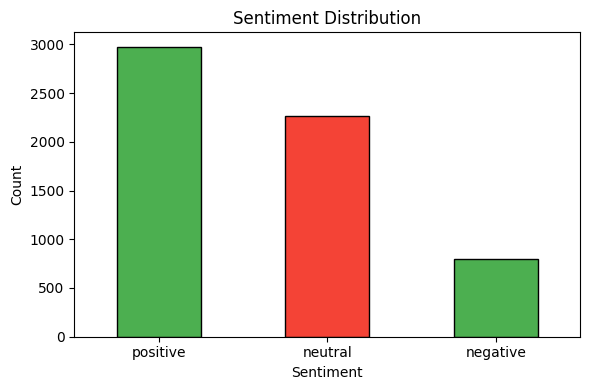

In [22]:
print("Sentiment distribution:")
print(df['sentiment'].value_counts())

fig, ax = plt.subplots(figsize=(6, 4))
df['sentiment'].value_counts().plot(kind='bar', ax=ax, color=['#4CAF50','#F44336'], edgecolor='black')
ax.set_title('Sentiment Distribution')
ax.set_xlabel('Sentiment')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

## 3. Text Preprocessing

In [23]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = text.replace('#', '')

    # 🔥 NEGATION FIX
    text = text.replace("not ", "NOT_")
    text = text.replace("no ", "NO_")

    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)

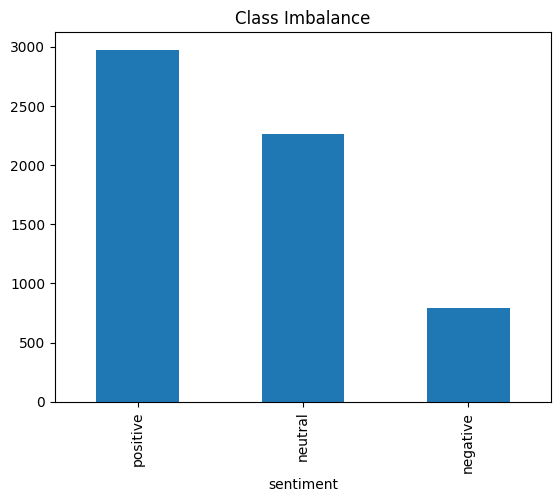

In [24]:
df['sentiment'].value_counts().plot(kind='bar')
plt.title("Class Imbalance")
plt.show()

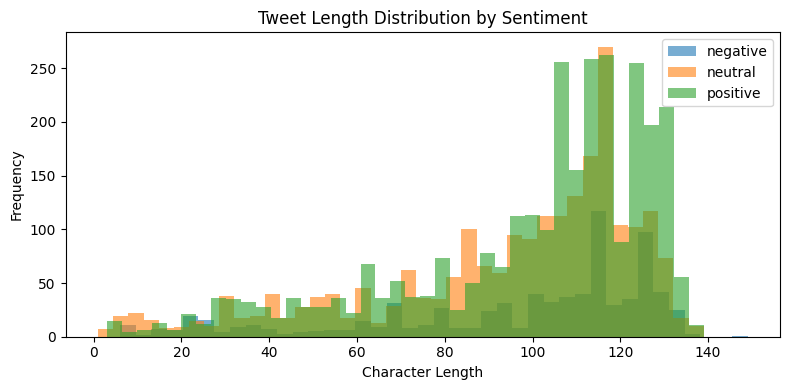

In [25]:
# Show tweet length distribution
df['tweet_length'] = df['clean_text'].apply(len)
fig, ax = plt.subplots(figsize=(8, 4))
df.groupby('sentiment')['tweet_length'].plot(kind='hist', alpha=0.6, bins=40, ax=ax, legend=True)
ax.set_title('Tweet Length Distribution by Sentiment')
ax.set_xlabel('Character Length')
plt.tight_layout()
plt.show()

# 4. Train-Test Split

In [26]:
X = df['clean_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## 5. Feature Engineering — TF-IDF Vectorization

In [27]:
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=10000,
    ngram_range=(1,2)
)

# 6. Model Training and Comparison

In [28]:
nb_model = ComplementNB(alpha=0.5)

pipeline_nb = Pipeline([
    ('tfidf', tfidf),
    ('nb', nb_model)
])

pipeline_nb.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=10000, ngram_range=(1, 2),
                                 stop_words='english')),
                ('nb', ComplementNB(alpha=0.5))])

In [29]:
y_pred = pipeline_nb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8724109362054681

Classification Report:

              precision    recall  f1-score   support

    negative       0.73      0.83      0.78       159
     neutral       0.91      0.82      0.86       453
    positive       0.89      0.92      0.91       595

    accuracy                           0.87      1207
   macro avg       0.84      0.86      0.85      1207
weighted avg       0.88      0.87      0.87      1207



# 7. Model Comparison

                 Model  Accuracy
0       Multinomial NB  0.881524
1        Complement NB  0.880696
2  Logistic Regression  0.891466


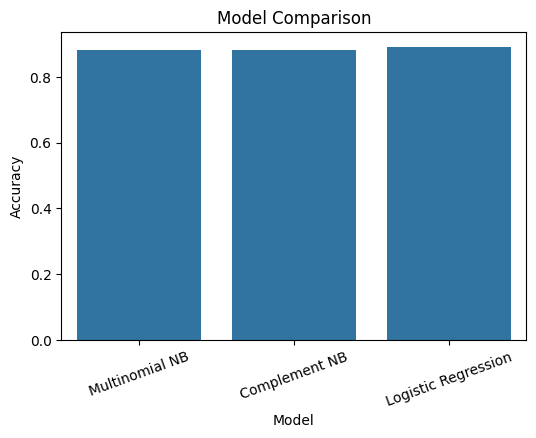

In [30]:
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy'])
print(results_df)

plt.figure(figsize=(6,4))
sns.barplot(data=results_df, x='Model', y='Accuracy')
plt.xticks(rotation=20)
plt.title("Model Comparison")
plt.show()

# 8. Confusion Matrix

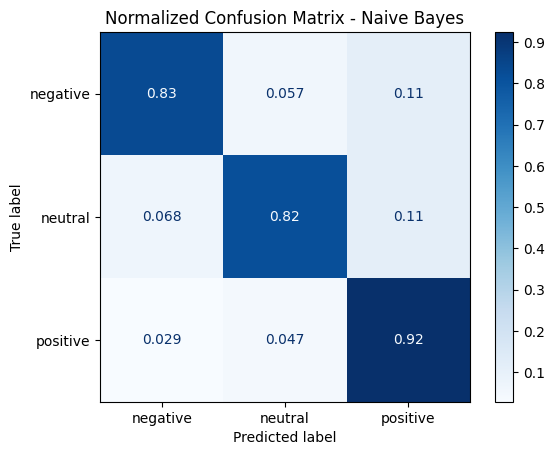

In [31]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    normalize='true',
    cmap='Blues'
)
plt.title("Normalized Confusion Matrix - Naive Bayes")
plt.show()

#9. Cross Validation

In [32]:
cv_scores = cross_val_score(pipeline_nb, X, y, cv=5, scoring='accuracy')

print("CV Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

CV Scores: [0.57166529 0.64788732 0.75124378 0.65091211 0.64344942]
Mean CV Accuracy: 0.6530315833151283


#10.Sample Predictions

In [40]:
samples = [
    "I love this product!",
    "This is the worst experience ever.",
    "Applications are open until Friday.",
    "Absolutely fantastic service!",
    "I am disappointed with the results.",
    "Registration for the event closes tomorrow.",
    "The event is scheduled for tomorrow."
]

for t in samples:
    print(t, "→", pipeline_nb.predict([t])[0])

I love this product! → positive
This is the worst experience ever. → negative
Applications are open until Friday. → neutral
Absolutely fantastic service! → positive
I am disappointed with the results. → negative
Registration for the event closes tomorrow. → neutral
The event is scheduled for tomorrow. → neutral


In [15]:
df['sentiment'].value_counts()

,count
sentiment,
positive,2974
neutral,2262
negative,796


# 11.Probability Examples

In [35]:
tweet = "The meeting starts at 3 PM."
probs = pipeline_nb.predict_proba([tweet])[0]

for cls, p in zip(pipeline_nb.classes_, probs):
    print(cls, ":", round(p, 4))

negative : 0.3105
neutral : 0.2954
positive : 0.394


## Summary

Best model is selected based on accuracy and cross-validation results.

Logistic Regression provides strong performance alongside Naive Bayes models.

Naive Bayes works well for high-dimensional sparse text data like TF-IDF.

Neutral sentiment remains the most difficult class due to lack of strong polarity signals.

Overall, the system is suitable for real-world sentiment classification tasks.